In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [30]:
# Load the dataset
train_encoded = pd.read_csv('encoded_data/train_encoded.csv')
test_encoded = pd.read_csv('encoded_data/test_encoded.csv')

# Prepare X and y for modeling
X = train_encoded.drop(['id', 'accident_risk'], axis=1)
y = train_encoded['accident_risk']
# Prepare test data
X_test = test_encoded.drop(['id','accident_risk'], axis=1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")


X shape: (517754, 17)
y shape: (517754,)
X_test shape: (172585, 17)


In [31]:
# Split data for training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (414203, 17)
X_val shape: (103551, 17)


In [38]:
#function to evaluate model performance
def evaluate_model(model, X_train, y_train, X_val, y_val):
    
    #train model
    model.fit(X_train, y_train)

    #make predictions
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    #calculate RMSE
    train_rmse = np.sqrt(np.mean((y_train - train_preds) ** 2))
    val_rmse = np.sqrt(np.mean((y_val - val_preds) ** 2))

    return train_rmse, val_rmse

In [40]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    train_rmse, val_rmse = evaluate_model(model, X_train, y_train, X_val, y_val)
    results[name] = {'Train RMSE': train_rmse, 'Validation RMSE': val_rmse}
    print(f"{name} - Train RMSE: {train_rmse:.4f}, Validation RMSE: {val_rmse:.4f}")
    print("-" * 40)

Training Linear Regression...
Linear Regression - Train RMSE: 0.0735, Validation RMSE: 0.0735
----------------------------------------
Training Decision Tree...


/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

Decision Tree - Train RMSE: 0.0073, Validation RMSE: 0.0830
----------------------------------------
Training Random Forest...
Random Forest - Train RMSE: 0.0230, Validation RMSE: 0.0597
----------------------------------------
Training XGBoost...
XGBoost - Train RMSE: 0.0553, Validation RMSE: 0.0564
----------------------------------------


<Figure size 1200x800 with 0 Axes>

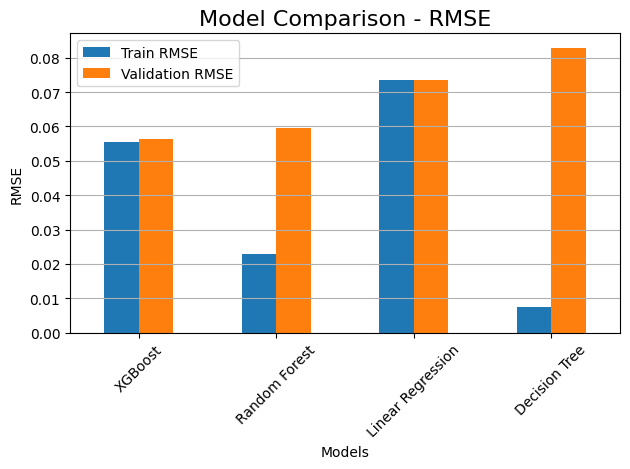

                   Train RMSE  Validation RMSE
XGBoost              0.055341         0.056383
Random Forest        0.023007         0.059685
Linear Regression    0.073484         0.073529
Decision Tree        0.007305         0.082973


In [41]:
# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Validation RMSE')

# Plot results
plt.figure(figsize=(12, 8))
results_df.plot(kind='bar')
plt.title('Model Comparison - RMSE', fontsize=16)
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(results_df)